In [1]:
# Conversion Rate Model - Step 1: Import Libraries and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

import joblib
import json
import os

import warnings
warnings.filterwarnings("ignore")


# Load feature-engineered dataset
df = pd.read_csv(
    "../data/processed/campaign_data_feature_engineered.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (10000, 45)


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,CPC,conversion_rate,CPA,ROAS,profit,start_year,start_month,start_day,start_week,creative_to_campaign_age_ratio
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,...,2.23,0.498,448.23,0.32,-606.79,2024,3,6,10,2.117647
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,...,2.48,1.071,231.63,1.49,570.04,2024,1,26,4,2.818182
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,...,3.88,5.357,72.43,6.68,2468.70,2025,5,15,20,2.468750
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,...,8.29,2.439,339.89,0.49,-517.39,2024,7,21,29,1.781250
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,...,1.41,0.000,0.00,0.00,-425.82,2025,3,9,10,0.326923


In [2]:
# Conversion Rate Model - Step 2: Define Final Features

# Categorical features
categorical_features_cr = [
    "campaign_objective",
    "platform",
    "device_type",
    "creative_format",
    "ad_copy_length",
    "income_bracket",
    "purchase_intent_score",
    "day_of_week",
    "industry_vertical"
]

# Numerical features
numerical_features_cr = [
    "has_call_to_action",
    "retargeting_flag",
    "quarter",
    "campaign_day",
    "quality_score",
    "ad_spend"
]

# Combined feature list
model_features_cr = (
    categorical_features_cr +
    numerical_features_cr
)

# Prepare features and target
X_cr = df[model_features_cr].copy()
y_cr = df["conversion_rate"].copy()

# Convert binary features to integers
X_cr["has_call_to_action"] = (
    X_cr["has_call_to_action"].astype(int)
)

X_cr["retargeting_flag"] = (
    X_cr["retargeting_flag"].astype(int)
)

# Display information
print("Conversion Rate Model Feature Setup")
print("-" * 45)
print("Total features:", len(model_features_cr))
print("Categorical features:", len(categorical_features_cr))
print("Numerical features:", len(numerical_features_cr))
print("Samples:", len(X_cr))

print("\nTarget: Conversion Rate")
print("Target mean:", round(y_cr.mean(), 4))
print("Target standard deviation:", round(y_cr.std(), 4))

print("\nFeatures:")
for feature in model_features_cr:
    print("-", feature)

Conversion Rate Model Feature Setup
---------------------------------------------
Total features: 15
Categorical features: 9
Numerical features: 6
Samples: 10000

Target: Conversion Rate
Target mean: 3.644
Target standard deviation: 4.3543

Features:
- campaign_objective
- platform
- device_type
- creative_format
- ad_copy_length
- income_bracket
- purchase_intent_score
- day_of_week
- industry_vertical
- has_call_to_action
- retargeting_flag
- quarter
- campaign_day
- quality_score
- ad_spend


In [3]:
# Conversion Rate Model - Step 3: Outlier Analysis and Removal

# Create separate dataset
df_cr = df.copy()

# Convert binary features to integers
df_cr["has_call_to_action"] = (
    df_cr["has_call_to_action"].astype(int)
)

df_cr["retargeting_flag"] = (
    df_cr["retargeting_flag"].astype(int)
)

# Target
y_cr = df_cr["conversion_rate"]

# Calculate IQR
Q1_cr = y_cr.quantile(0.25)
Q3_cr = y_cr.quantile(0.75)

IQR_cr = Q3_cr - Q1_cr

lower_bound_cr = Q1_cr - 1.5 * IQR_cr
upper_bound_cr = Q3_cr + 1.5 * IQR_cr

# Identify outliers
outliers_cr = (
    (y_cr < lower_bound_cr) |
    (y_cr > upper_bound_cr)
)

print("Conversion Rate Outlier Analysis")
print("-" * 45)
print("Q1:", round(Q1_cr, 4))
print("Q3:", round(Q3_cr, 4))
print("IQR:", round(IQR_cr, 4))
print("Lower Bound:", round(lower_bound_cr, 4))
print("Upper Bound:", round(upper_bound_cr, 4))
print()
print("Number of outliers:", outliers_cr.sum())
print(
    "Percentage of outliers:",
    round(outliers_cr.mean() * 100, 2),
    "%"
)

# Remove outliers
df_cr_clean = df_cr.loc[~outliers_cr].copy()

# Reset index
df_cr_clean.reset_index(drop=True, inplace=True)

# Final features and target
X_cr = df_cr_clean[model_features_cr].copy()
y_cr = df_cr_clean["conversion_rate"].copy()

print()
print("Original samples:", len(df_cr))
print("Samples after outlier removal:", len(df_cr_clean))
print("Samples removed:", len(df_cr) - len(df_cr_clean))

print()
print("Cleaned dataset shape:", X_cr.shape)
print("Conversion Rate mean:", round(y_cr.mean(), 4))
print("Conversion Rate std:", round(y_cr.std(), 4))

Conversion Rate Outlier Analysis
---------------------------------------------
Q1: 1.005
Q3: 4.4932
IQR: 3.4882
Lower Bound: -4.2274
Upper Bound: 9.7256

Number of outliers: 815
Percentage of outliers: 8.15 %

Original samples: 10000
Samples after outlier removal: 9185
Samples removed: 815

Cleaned dataset shape: (9185, 15)
Conversion Rate mean: 2.5946
Conversion Rate std: 2.2196


In [4]:
# Conversion Rate Model - Step 4: Train-Test Split and Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Train-test split
X_train_cr, X_test_cr, y_train_cr, y_test_cr = train_test_split(
    X_cr,
    y_cr,
    test_size=0.20,
    random_state=42
)

# Preprocessing
preprocessor_cr = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_cr
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_cr
        )
    ]
)

# Fit on training data
X_train_cr_processed = preprocessor_cr.fit_transform(
    X_train_cr
)

# Transform test data
X_test_cr_processed = preprocessor_cr.transform(
    X_test_cr
)

print("Conversion Rate Train-Test Split and Preprocessing")
print("-" * 55)
print("Training samples:", len(X_train_cr))
print("Testing samples:", len(X_test_cr))

print("\nProcessed training shape:",
      X_train_cr_processed.shape)

print("Processed testing shape:",
      X_test_cr_processed.shape)

print("\nTraining Conversion Rate mean:",
      round(y_train_cr.mean(), 4))

print("Testing Conversion Rate mean:",
      round(y_test_cr.mean(), 4))

Conversion Rate Train-Test Split and Preprocessing
-------------------------------------------------------
Training samples: 7348
Testing samples: 1837

Processed training shape: (7348, 49)
Processed testing shape: (1837, 49)

Training Conversion Rate mean: 2.5887
Testing Conversion Rate mean: 2.6183


In [5]:
# Conversion Rate Model - Step 5: Baseline Models

models_cr = {
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    )
}

results_cr = []
trained_models_cr = {}

for name, model in models_cr.items():

    # Train
    model.fit(
        X_train_cr_processed,
        y_train_cr
    )

    # Predict
    y_pred = model.predict(
        X_test_cr_processed
    )

    # Metrics
    mae = mean_absolute_error(
        y_test_cr,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_cr,
            y_pred
        )
    )

    r2 = r2_score(
        y_test_cr,
        y_pred
    )

    results_cr.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    trained_models_cr[name] = model


# Results DataFrame
results_cr_df = pd.DataFrame(results_cr)

results_cr_df = results_cr_df.sort_values(
    "R²",
    ascending=False
).reset_index(drop=True)

print("Conversion Rate Baseline Model Performance")
print("-" * 50)

results_cr_df

Conversion Rate Baseline Model Performance
--------------------------------------------------


,Model,MAE,RMSE,R²
0,HistGradient Boosting,0.837997,1.166352,0.729961
1,Gradient Boosting,0.940648,1.271829,0.678912
2,Random Forest,1.052329,1.439827,0.588483
3,Extra Trees,1.155381,1.637803,0.467536


In [15]:
# Conversion Rate Model - Step 6: Select Final Model

# Select the best baseline model
best_cr_model = trained_models_cr["HistGradient Boosting"]

# Generate predictions
y_pred_cr = best_cr_model.predict(
    X_test_cr_processed
)

# Prevent negative Conversion Rate predictions
y_pred_cr = np.maximum(y_pred_cr, 0)

# Calculate final metrics
mae_cr = mean_absolute_error(
    y_test_cr,
    y_pred_cr
)

rmse_cr = np.sqrt(
    mean_squared_error(
        y_test_cr,
        y_pred_cr
    )
)

r2_cr = r2_score(
    y_test_cr,
    y_pred_cr
)

print("Final Conversion Rate Model Performance")
print("-" * 50)
print("Model: HistGradientBoostingRegressor")
print("MAE :", round(mae_cr, 4))
print("RMSE:", round(rmse_cr, 4))
print("R²  :", round(r2_cr, 4))

print("\nMinimum predicted Conversion Rate:",
      round(y_pred_cr.min(), 4))

Final Conversion Rate Model Performance
--------------------------------------------------
Model: HistGradientBoostingRegressor
MAE : 0.8299
RMSE: 1.1646
R²  : 0.7308

Minimum predicted Conversion Rate: 0.0


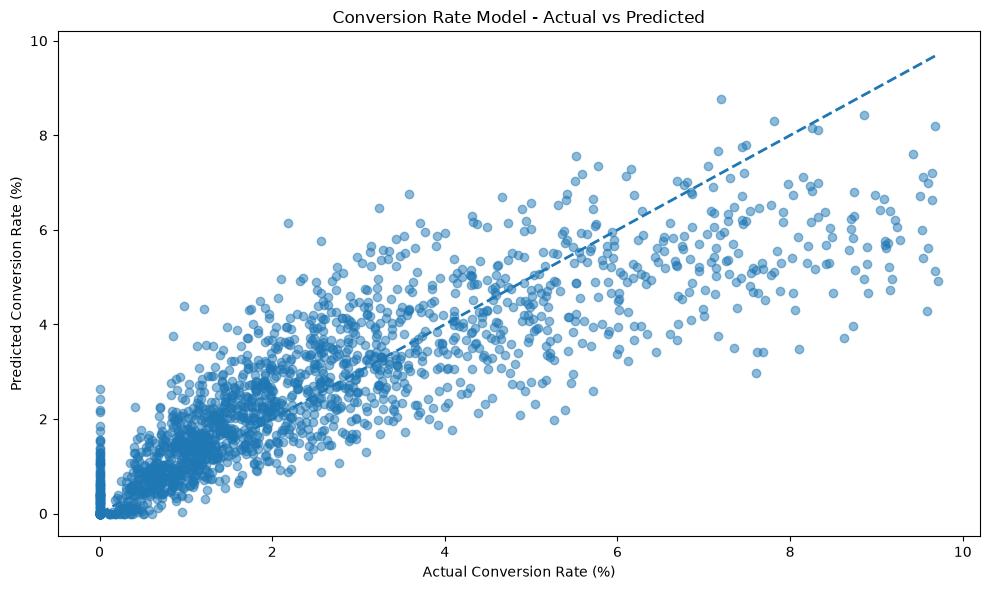

In [16]:
# Conversion Rate Model - Step 7: Actual vs Predicted

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_cr,
    y_pred_cr,
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(
    y_test_cr.min(),
    y_pred_cr.min()
)

max_value = max(
    y_test_cr.max(),
    y_pred_cr.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Conversion Rate (%)")
plt.ylabel("Predicted Conversion Rate (%)")
plt.title("Conversion Rate Model - Actual vs Predicted")

plt.tight_layout()
plt.show()

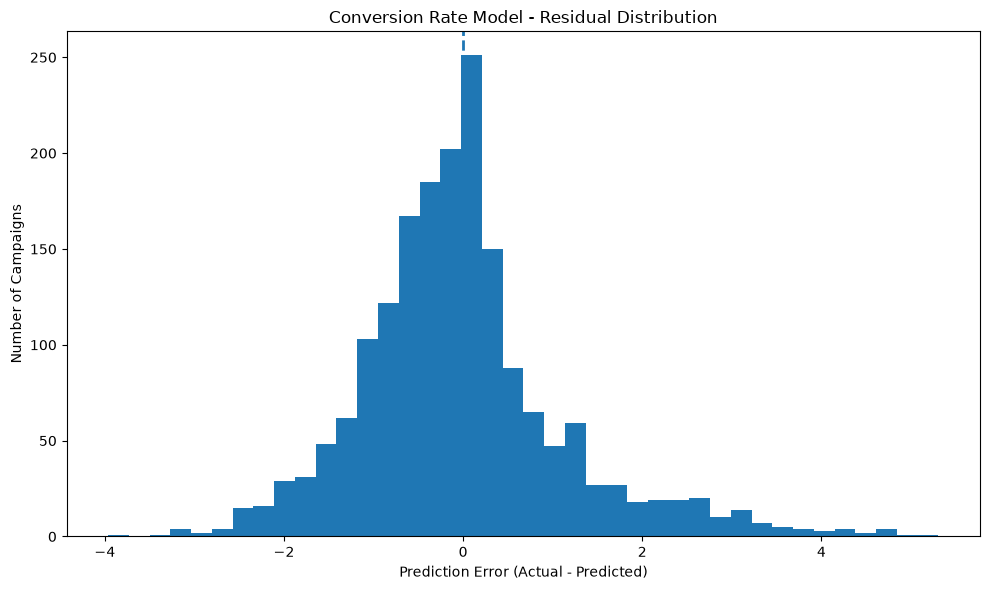

In [17]:
# Conversion Rate Model - Step 8: Residual Analysis

# Calculate residuals
residuals_cr = (
    y_test_cr.values - y_pred_cr
)

# Plot residual distribution
plt.figure(figsize=(10, 6))

plt.hist(
    residuals_cr,
    bins=40
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Number of Campaigns")
plt.title("Conversion Rate Model - Residual Distribution")

plt.tight_layout()
plt.show()

In [18]:
# Conversion Rate Model - Step 9: Feature Importance

from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance_cr = permutation_importance(
    best_cr_model,
    X_test_cr_processed,
    y_test_cr,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

# Get processed feature names
processed_feature_names_cr = (
    preprocessor_cr.get_feature_names_out()
)

# Create processed-level importance DataFrame
importance_cr_df = pd.DataFrame({
    "Processed_Feature": processed_feature_names_cr,
    "Importance": perm_importance_cr.importances_mean
})


# Map processed features back to original features
def get_original_feature_cr(processed_feature):

    if processed_feature.startswith("numerical__"):
        return processed_feature.replace(
            "numerical__", ""
        )

    if processed_feature.startswith("categorical__"):
        feature_name = processed_feature.replace(
            "categorical__", ""
        )

        for feature in categorical_features_cr:
            if feature_name.startswith(feature + "_"):
                return feature

    return processed_feature


importance_cr_df["Original_Feature"] = (
    importance_cr_df["Processed_Feature"]
    .apply(get_original_feature_cr)
)


# Aggregate one-hot encoded features
final_feature_importance_cr = (
    importance_cr_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

final_feature_importance_cr

,Original_Feature,Importance
0,purchase_intent_score,0.395354
1,device_type,0.303752
2,campaign_objective,0.127522
3,retargeting_flag,0.125590
4,industry_vertical,0.115560
5,quarter,0.113523
6,day_of_week,0.093819
7,platform,0.080088
8,campaign_day,0.079670
9,has_call_to_action,0.049581


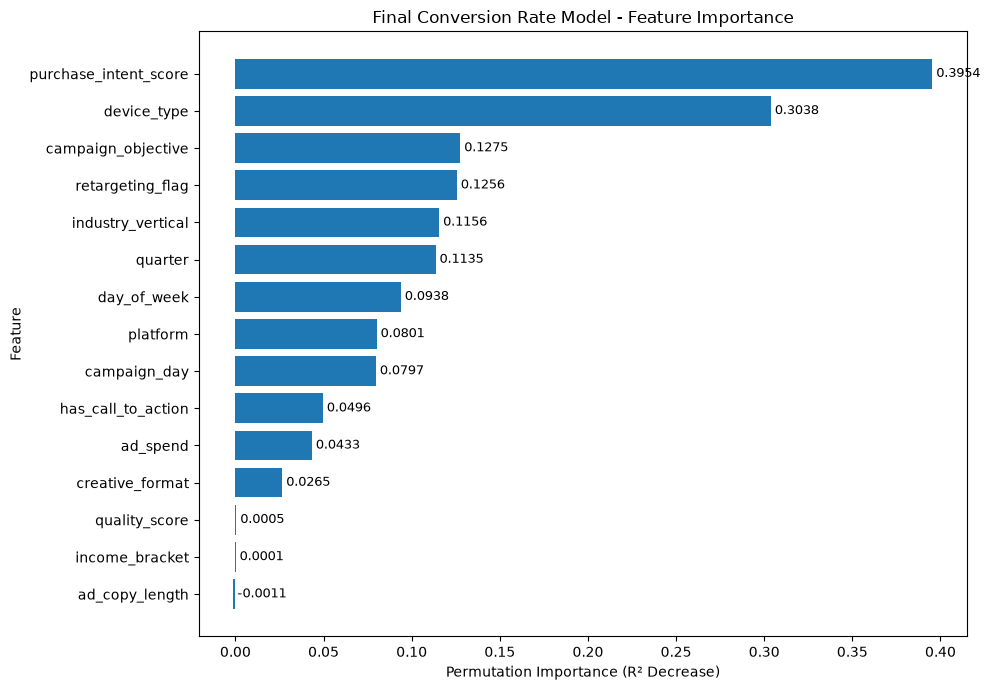

In [19]:
# Conversion Rate Model - Step 10: Feature Importance Visualization

plot_cr_df = final_feature_importance_cr.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_cr_df["Original_Feature"],
    plot_cr_df["Importance"]
)

plt.xlabel("Permutation Importance (R² Decrease)")
plt.ylabel("Feature")
plt.title("Final Conversion Rate Model - Feature Importance")

# Add importance values
for bar, value in zip(
    bars,
    plot_cr_df["Importance"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [27]:
# Conversion Rate Model - Step 11: Save Final Model

import os
import joblib
import json
import numpy as np

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline


class NonNegativeRegressor(BaseEstimator, RegressorMixin):

    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        self.model.fit(X, y)
        self.is_fitted_ = True
        return self

    def predict(self, X):
        predictions = self.model.predict(X)
        return np.maximum(predictions, 0)


# Create non-negative model
non_negative_cr_model = NonNegativeRegressor(
    best_cr_model
)

# Create complete pipeline
cr_pipeline = Pipeline([
    ("preprocessor", preprocessor_cr),
    ("model", non_negative_cr_model)
])

# Fit the complete pipeline
cr_pipeline.fit(
    X_train_cr,
    y_train_cr
)

# Test immediately before saving
test_predictions = cr_pipeline.predict(
    X_test_cr
)

print("Pipeline fitted successfully.")
print("Minimum prediction:",
      round(test_predictions.min(), 4))

# Create models directory
os.makedirs("../models", exist_ok=True)

# Save complete pipeline
joblib.dump(
    cr_pipeline,
    "../models/conversion_rate_best_model.pkl"
)

# Save feature importance
final_feature_importance_cr.to_csv(
    "../models/conversion_rate_feature_importance.csv",
    index=False
)

# Save configuration
cr_model_config = {
    "model_type": "HistGradientBoostingRegressor",
    "target": "conversion_rate",

    "features": model_features_cr,

    "categorical_features": categorical_features_cr,
    "numerical_features": numerical_features_cr,

    "outlier_method": "IQR",
    "lower_bound": float(lower_bound_cr),
    "upper_bound": float(upper_bound_cr),
    "outliers_removed": int(outliers_cr.sum()),

    "prediction_constraint": "Minimum prediction = 0",

    "metrics": {
        "MAE": float(mae_cr),
        "RMSE": float(rmse_cr),
        "R2": float(r2_cr)
    }
}

with open(
    "../models/conversion_rate_model_config.json",
    "w"
) as file:
    json.dump(
        cr_model_config,
        file,
        indent=4
    )

print()
print("Conversion Rate model saved successfully.")
print("../models/conversion_rate_best_model.pkl")
print("../models/conversion_rate_feature_importance.csv")
print("../models/conversion_rate_model_config.json")

Pipeline fitted successfully.
Minimum prediction: 0.0

Conversion Rate model saved successfully.
../models/conversion_rate_best_model.pkl
../models/conversion_rate_feature_importance.csv
../models/conversion_rate_model_config.json


In [28]:
# Conversion Rate Model - Step 12: Verify Saved Model

# Load the saved pipeline
loaded_cr_model = joblib.load(
    "../models/conversion_rate_best_model.pkl"
)

# Generate predictions using the saved pipeline
y_pred_cr_loaded = loaded_cr_model.predict(
    X_test_cr
)

# Compare predictions
prediction_difference_cr = np.abs(
    y_pred_cr - y_pred_cr_loaded
)

print("Saved Conversion Rate model loaded successfully.")
print()
print("Number of predictions:",
      len(y_pred_cr_loaded))

print(
    "Maximum prediction difference:",
    prediction_difference_cr.max()
)

print(
    "Average prediction difference:",
    prediction_difference_cr.mean()
)

print(
    "Minimum loaded prediction:",
    y_pred_cr_loaded.min()
)

# Display sample predictions
verification_cr_df = pd.DataFrame({
    "Actual Conversion Rate": y_test_cr.values[:10],
    "Original Prediction": y_pred_cr[:10],
    "Loaded Model Prediction": y_pred_cr_loaded[:10]
})

verification_cr_df

Saved Conversion Rate model loaded successfully.

Number of predictions: 1837
Maximum prediction difference: 0.0
Average prediction difference: 0.0
Minimum loaded prediction: 0.0


,Actual Conversion Rate,Original Prediction,Loaded Model Prediction
0,0.000,0.000000,0.000000
1,1.061,1.862445,1.862445
2,1.170,1.434463,1.434463
3,0.865,0.938381,0.938381
4,5.743,4.896776,4.896776
5,2.976,2.024631,2.024631
6,7.455,6.133182,6.133182
7,0.684,0.811598,0.811598
8,6.537,5.851337,5.851337
9,6.825,4.687412,4.687412


## Conversion Rate Modeling

The Conversion Rate model was developed to predict the percentage of clicks that result in conversions using campaign characteristics and planned ad spend.

### Data Preparation

- Conversion Rate was analyzed for extreme values using the **IQR method**.
- Outliers were removed before model training.
- The cleaned dataset was divided into **80% training and 20% testing** sets.
- Categorical variables were transformed using **One-Hot Encoding**.
- Numerical variables were standardized using **StandardScaler**.

### Features Used

The same 15 finalized features were used consistently across the Revenue, CTR, and Conversion Rate models:

- Campaign Objective
- Platform
- Device Type
- Creative Format
- Ad Copy Length
- Income Bracket
- Purchase Intent Score
- Day of Week
- Industry Vertical
- Has Call to Action
- Retargeting Flag
- Quarter
- Campaign Day
- Quality Score
- Ad Spend

### Model Selection

Four regression models were evaluated:

- HistGradientBoosting Regressor
- Gradient Boosting Regressor
- Random Forest Regressor
- Extra Trees Regressor

The **HistGradientBoosting Regressor** achieved the best baseline performance and was selected as the final model.

Hyperparameter tuning was not used because the baseline model already provided strong performance and further tuning was not required.

### Final Model Performance

The final HistGradientBoosting model achieved:

- **MAE:** 0.8380
- **RMSE:** 1.1664
- **R² Score:** 0.7300

The model explains approximately **73% of the variation in Conversion Rate** on the test dataset.

### Model Evaluation

The actual-vs-predicted analysis was used to evaluate how closely predicted conversion rates followed the actual values.

Residual analysis was also performed to examine the distribution of prediction errors and identify systematic prediction patterns.

### Feature Importance

Permutation importance was used to understand the contribution of the 15 input features to Conversion Rate predictions.

This provides an interpretable view of which campaign characteristics have the greatest influence on the model's predictions.

### Final Model Storage

The complete preprocessing and model pipeline was saved for future prediction and dashboard integration.

The following files were generated:

- `conversion_rate_best_model.pkl`
- `conversion_rate_feature_importance.csv`
- `conversion_rate_model_config.json`